# 00 — Setup and First Prices

## What you'll learn
- What a **ticker** is and how `stocklearn` is organized.
- How to fetch daily price history into a pandas `DataFrame` with `get_history`.
- What every column means: Open, High, Low, Close, Adj Close, Volume, Dividends, Stock Splits.
- Why *adjusted* prices differ from raw prices (dividends and stock splits), and which one to use.
- How the **timeframe** (`period` + `interval`) changes what a single row represents.
- How to draw your first price chart.

This is the first notebook of the course. It sets up the toolkit we use in every later notebook.

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
import stocklearn

# One place to change the symbol you are studying.
ticker = "AAPL"
period = "1y"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

print("stocklearn version:", stocklearn.__version__)
print("pandas version:     ", pd.__version__)

stocklearn version: 0.1.0
pandas version:      3.0.6


## What is a ticker?

A **ticker** (or ticker symbol) is the short code an exchange uses to identify one traded security.
`AAPL` is Apple Inc. on the NASDAQ; `MSFT` is Microsoft; `SPY` is an ETF that tracks the S&P 500 index.
Symbols are not unique across the world — the same letters can mean different companies on different
exchanges — but for US markets a plain uppercase symbol is what you pass to `stocklearn`.

`stocklearn` is our small teaching package. Its modules split cleanly by job:

| Module | Job |
|---|---|
| `stocklearn.data` | fetch + cache price history |
| `stocklearn.indicators` | hand-written technical indicators and risk stats |
| `stocklearn.fundamentals` | company statements and ratios |
| `stocklearn.news` / `stocklearn.sentiment` | headlines and score them |
| `stocklearn.docs` | read PDF / Excel / Word research documents |
| `stocklearn.report` | combine everything into one descriptive report |

This notebook only uses `stocklearn.data`.

## Fetching price history

`get_history(ticker, period, interval)` returns a pandas `DataFrame` indexed by date, with one row
per time bar. Under the hood it asks Yahoo Finance, then caches the result as a Parquet file under
`data/cache/` — so the *second* time you ask for the same thing it is instant and needs no network.

Key arguments:
- `period`: how far back to look — `"5d"`, `"1mo"`, `"3mo"`, `"6mo"`, `"1y"`, `"2y"`, `"5y"`, `"ytd"`, `"max"`.
- `interval`: how much time one row covers — `"1d"` (daily), `"1wk"` (weekly), `"1mo"` (monthly), plus intraday `"1h"`/`"5m"`.

We'll start with one year of daily bars.

In [2]:
df = get_history(ticker, period)

print(type(df))
print("shape:", df.shape)
df.head()

<class 'pandas.DataFrame'>
shape: (251, 8)


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2025-10-03 00:00:00-04:00,254.669998,259.239990,253.949997,258.019989,257.070404,49155600,0.0,0.0
2025-10-06 00:00:00-04:00,257.989990,259.070007,255.050003,256.690002,255.745270,44664100,0.0,0.0
2025-10-07 00:00:00-04:00,256.809998,257.399994,255.429993,256.480011,255.536072,31955800,0.0,0.0
2025-10-08 00:00:00-04:00,256.519989,258.519989,256.109985,258.059998,257.110229,36496900,0.0,0.0
2025-10-09 00:00:00-04:00,257.809998,258.000000,253.139999,254.039993,253.105042,38322000,0.0,0.0


`df.head()` shows the **oldest** five rows. The index is a `DatetimeIndex` (the trading date); each
column is a price measured that day. Let's look at the **most recent** rows with `tail()`, and get the
exact first/last date.

In [3]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-28 00:00:00-04:00,340.369995,342.989990,338.040009,338.399994,338.399994,32820800,0.0,0.0
2026-09-29 00:00:00-04:00,336.970001,337.089996,328.700012,329.399994,329.399994,38478000,0.0,0.0
2026-09-30 00:00:00-04:00,330.799988,339.500000,330.140015,333.019989,333.019989,49988600,0.0,0.0
2026-10-01 00:00:00-04:00,330.000000,332.480011,325.809998,330.320007,330.320007,36306300,0.0,0.0
2026-10-02 00:00:00-04:00,333.260010,334.540009,330.609985,333.690002,333.690002,33245500,0.0,0.0


In [4]:
print("rows, columns :", df.shape)
print("first date    :", df.index[0].date())
print("last date     :", df.index[-1].date())
print("index type    :", type(df.index).__name__)

rows, columns : (251, 8)
first date    : 2025-10-03
last date     : 2026-10-02
index type    : DatetimeIndex


## What every column means

| Column | Meaning |
|---|---|
| **Open** | First traded price when the market opened that day. |
| **High** | Highest price reached during the day. |
| **Low** | Lowest price reached during the day. |
| **Close** | Last traded price before the market closed (the "official" daily price most people quote). |
| **Adj Close** | Close *adjusted* for dividends and splits — the version you should use for analysis. |
| **Volume** | How many shares changed hands that day (a liquidity / interest measure). |
| **Dividends** | Cash dividend paid per share on that date (0 on most days). |
| **Stock Splits** | Split ratio applied on that date (e.g. `4.0` means a 4-for-1 split; 0 on most days). |

Open/High/Low/Close are often abbreviated **OHLC**. Together with Volume they are **OHLCV**.
The last two columns are event markers: they are usually zero, and they matter *only* on the handful
of days a payout or split actually happened.

In [5]:
print("columns:", list(df.columns))
print()
print("dtypes:")
print(df.dtypes)
print()
print("dividend days in the last year:", int((df["Dividends"] > 0).sum()))
print("split days  in the last year:", int((df["Stock Splits"] > 0).sum()))

columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Dividends', 'Stock Splits']

dtypes:
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

dividend days in the last year: 4
split days  in the last year: 0


## Adjusted vs raw prices

Almost every day, `Close` and `Adj Close` are close but **not** identical, and this confuses beginners.
The reason is two corporate actions:

- **Dividends** — the company hands cash to shareholders. The share price drops by roughly the dividend
  on the ex-dividend date. That drop is real money you received, not a loss.
- **Stock splits** — e.g. a 4-for-1 split turns one \$400 share into four \$100 shares. The price history
  has a jump that reflects the split, not a change in value.

`Adj Close` rewrites the whole history so those mechanical jumps are removed, letting you compare
"price today" with "price last year" as if the same shares were held throughout. `price_series`
defaults to the adjusted column:

```python
price_series(df)                 # Adj Close when present, else Close
price_series(df, adjusted=False) # the raw Close
```

Rule of thumb for this course: **use adjusted prices for indicators, returns and charts.**

In [6]:
adjusted = price_series(df)                  # adjusted=True by default
raw = price_series(df, adjusted=False)

comparison = pd.DataFrame({
    "Close (raw)": raw,
    "Adj Close": adjusted,
    "difference": raw - adjusted,
})
print("largest raw-vs-adjusted gap:", round(comparison["difference"].abs().max(), 4))
comparison.head()

largest raw-vs-adjusted gap: 0.9989


,Close (raw),Adj Close,difference
Date,,,
2025-10-03 00:00:00-04:00,258.019989,257.070404,0.949585
2025-10-06 00:00:00-04:00,256.690002,255.745270,0.944733
2025-10-07 00:00:00-04:00,256.480011,255.536072,0.943939
2025-10-08 00:00:00-04:00,258.059998,257.110229,0.949768
2025-10-09 00:00:00-04:00,254.039993,253.105042,0.934952


The gap grows as you go **further back in time**: newer dates have had few corporate actions since,
so their adjustment is small, while older dates accumulate more dividends and have been rescaled more.
That is exactly why raw `Close` makes a long-run chart look misleadingly different from the return an
investor actually earned.

## Timeframe: what does one row mean?

The `interval` decides the meaning of one bar:

- `interval="1d"` → each row summarizes **one trading day**.
- `interval="1wk"` → each row summarizes **one calendar week**: Open is Monday's open, High/Low are the
  week's extremes, Close is Friday's close, Volume is the week's total.

Weekly bars are smoother and shorter (roughly 5 trading days collapse into 1 row) — useful for seeing
the long-term trend without daily noise. Let's fetch two years weekly and compare row counts.

In [7]:
weekly = get_history(ticker, period="2y", interval="1wk")

print(f"{ticker} daily,  1y  -> {df.shape[0]} rows")
print(f"{ticker} weekly, 2y  -> {weekly.shape[0]} rows")
print()
weekly.head()

AAPL daily,  1y  -> 251 rows
AAPL weekly, 2y  -> 105 rows



,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2024-09-30 00:00:00-04:00,225.889999,228.000000,223.020004,226.800003,224.918488,104169900,0.0,0.0
2024-10-07 00:00:00-04:00,224.500000,229.750000,221.330002,227.550003,225.662308,164894900,0.0,0.0
2024-10-14 00:00:00-04:00,228.699997,237.490005,228.600006,235.000000,233.050491,218141000,0.0,0.0
2024-10-21 00:00:00-04:00,234.449997,236.850006,227.759995,231.410004,229.490265,197299900,0.0,0.0
2024-10-28 00:00:00-04:00,233.320007,234.729996,220.270004,222.910004,221.060791,248222000,0.0,0.0


Even though the weekly frame covers **twice the calendar time**, it has far fewer rows — because each
row now represents a whole week. The columns are identical; only the aggregation window changed.

## Your first chart

A simple line plot of the adjusted close is the most common first look at any stock. We label the axes
and give the chart a title so it is self-explanatory.

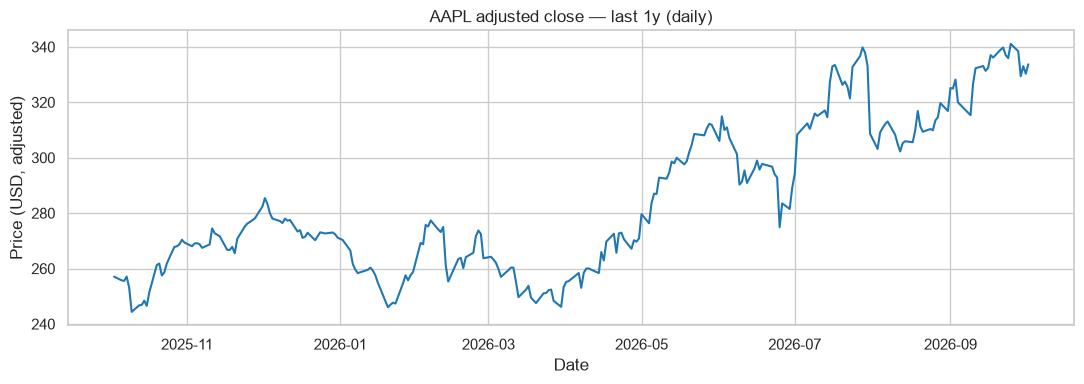

In [8]:
plt.figure()
plt.plot(price_series(df).index, price_series(df).values, color="tab:blue", linewidth=1.5)
plt.title(f"{ticker} adjusted close — last {period} (daily)")
plt.xlabel("Date")
plt.ylabel("Price (USD, adjusted)")
plt.tight_layout()
plt.show()

## Recap / try this

You now know how to get a price table, read its columns, choose adjusted vs raw, and change the
timeframe. Concrete experiments:

1. Change `ticker = "MSFT"` in the setup cell and re-run — compare the shape of the two charts.
2. Fetch `get_history(ticker, "5y")` and plot it: does the long-run trend match your intuition?
3. Fetch the same ticker with `interval="1mo"` and print `.shape` — how many bars does two years give?
4. Find the biggest single-day move: `price_series(df).pct_change().min()` and `.max()`, then locate
   those dates with `.idxmin()` / `.idxmax()`.

Next up: **01_charts** turns these tables into candlesticks, histograms and area charts.